# Expanded Metals Residual Strategy Visual Inspection

This notebook inspects `HYP-0011-expanded-metals-residual-basket`, the daily residual mean-reversion strategy on `GC`, `SI`, `HG`, `PL`, `PA`, and `ALI` using Databento `GLBX.MDP3` continuous daily futures data.

The plots cover data overlap, roll behavior, liquidity proxies, continuous prices and returns, residual z-scores, strategy positions, OOS performance, drawdowns, and asset-level contribution diagnostics.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update(
    {
        "figure.figsize": (12, 5),
        "axes.titlesize": 13,
        "axes.labelsize": 10,
        "legend.fontsize": 9,
    }
)

ROOT = Path.cwd()
EXPERIMENT_DIR = ROOT / "experiments" / "HYP-0011-expanded-metals-residual-basket"
CONTINUOUS_DIR = Path("/home/famadeo/research/databento-asset-browser/data/futures_continuous")
ROOTS = ["GC", "SI", "HG", "PL", "PA", "ALI"]

CONFIG_PATH = EXPERIMENT_DIR / "config.yaml"
RESULTS_PATH = EXPERIMENT_DIR / "results.json"
BUILD_REPORT_PATH = CONTINUOUS_DIR / "_build_report.csv"

with CONFIG_PATH.open("r", encoding="utf-8") as handle:
    config = yaml.safe_load(handle)
with RESULTS_PATH.open("r", encoding="utf-8") as handle:
    results = json.load(handle)

START = pd.Timestamp(config["data"].get("start")) if config["data"].get("start") else None
LOOKBACK = int(config["strategy"]["lookback_days"])
ENTRY_Z = float(config["strategy"]["entry_z"])
COST_BPS = float(config["strategy"]["cost_bps_per_unit_turnover"])

print(results["experiment_id"])
print(results["decision"])
print(f"Universe: {', '.join(ROOTS)}")
print(f"Start filter: {START.date() if START is not None else 'none'}")

HYP-0011-expanded-metals-residual-basket
{'status': 'revise', 'passed': True}
Universe: GC, SI, HG, PL, PA, ALI
Start filter: 2014-05-06


In [2]:
def parse_date_index(values: pd.Series) -> pd.DatetimeIndex:
    return pd.to_datetime(values, utc=True).dt.tz_convert(None).dt.normalize()


def load_continuous(root: str) -> pd.DataFrame:
    frame = pd.read_csv(CONTINUOUS_DIR / f"{root}.csv")
    frame["date"] = parse_date_index(frame["date"])
    frame = frame.set_index("date").sort_index()
    frame["root"] = root
    return frame


continuous = {root: load_continuous(root) for root in ROOTS}

price_panel = pd.concat(
    {root: frame["cont_logprice"] for root, frame in continuous.items()}, axis=1
)
close_panel = pd.concat({root: frame["cont_close"] for root, frame in continuous.items()}, axis=1)
return_panel = pd.concat({root: frame["cont_logret"] for root, frame in continuous.items()}, axis=1)
volume_panel = pd.concat({root: frame["volume"] for root, frame in continuous.items()}, axis=1)
roll_panel = pd.concat(
    {root: frame["is_roll"].astype(bool) for root, frame in continuous.items()}, axis=1
)
active_panel = pd.concat({root: frame["active"] for root, frame in continuous.items()}, axis=1)

if START is not None:
    price_panel = price_panel.loc[price_panel.index >= START]
    close_panel = close_panel.loc[close_panel.index >= START]
    return_panel = return_panel.loc[return_panel.index >= START]
    volume_panel = volume_panel.loc[volume_panel.index >= START]
    roll_panel = roll_panel.loc[roll_panel.index >= START]
    active_panel = active_panel.loc[active_panel.index >= START]

common_price_idx = price_panel.dropna(how="any").index
common_return_idx = return_panel.dropna(how="any").index
price_common = price_panel.loc[common_price_idx]
return_common = return_panel.loc[common_return_idx]
volume_common = volume_panel.reindex(common_price_idx)
roll_common = roll_panel.reindex(common_price_idx).fillna(False)

portfolio_returns = pd.read_csv(
    EXPERIMENT_DIR / "portfolio_returns.csv", parse_dates=["date"]
).set_index("date")
oos_returns = pd.read_csv(
    EXPERIMENT_DIR / "oos_portfolio_returns.csv", parse_dates=["date"]
).set_index("date")
positions = pd.read_parquet(EXPERIMENT_DIR / "positions.parquet")
positions.index = pd.to_datetime(positions.index)
positions = positions.sort_index()[ROOTS]
oos_positions = positions.reindex(oos_returns.index).fillna(0.0)

metrics = pd.Series(results["portfolio_metrics"]).to_frame("value")
metrics.loc["total_gross_return", "value"] = (
    f"{results['portfolio_metrics']['total_gross_return']:.2%}"
)
metrics.loc["total_cost_return", "value"] = (
    f"{results['portfolio_metrics']['total_cost_return']:.2%}"
)
metrics.loc["total_net_return", "value"] = f"{results['portfolio_metrics']['total_net_return']:.2%}"
metrics.loc["mean_net_bps", "value"] = f"{results['portfolio_metrics']['mean_net_bps']:.2f}"
metrics.loc["event_tstat", "value"] = f"{results['portfolio_metrics']['event_tstat']:.2f}"
metrics.loc["annualized_sharpe", "value"] = (
    f"{results['portfolio_metrics']['annualized_sharpe']:.2f}"
)
metrics.loc["hit_rate", "value"] = f"{results['portfolio_metrics']['hit_rate']:.2%}"
metrics.loc["max_drawdown", "value"] = f"{results['portfolio_metrics']['max_drawdown']:.2%}"

display(metrics)

/tmp/ipykernel_227886/2026156738.py:35: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  roll_common = roll_panel.reindex(common_price_idx).fillna(False)


,value
label,daily_residual_basket
observations,985
total_gross_return,44.85%
total_cost_return,5.50%
total_net_return,39.35%
mean_net_bps,3.99
event_tstat,1.85
annualized_sharpe,0.94
hit_rate,53.20%
max_drawdown,-14.92%


## Data Coverage And Roll Diagnostics

Start here to verify that the expanded complex is aligned and that the added roots do not introduce obvious data-quality problems.

Common overlap


,value
metric,
common_price_start,2014-05-06
common_price_end,2024-11-29
common_price_days,1849
common_return_start,2014-05-07
common_return_end,2024-11-29
common_return_days,1740


Per-root filtered coverage


,first_price,last_price,price_days,first_return,last_return,return_days,roll_days,median_volume
root,,,,,,,,
GC,2014-05-06,2024-11-29,3280,2014-05-06,2024-11-29,3280,54,156024.5
SI,2014-05-06,2024-11-29,3280,2014-05-06,2024-11-29,3280,54,48281.0
HG,2014-05-06,2024-11-29,3280,2014-05-06,2024-11-29,3280,54,50274.0
PL,2014-05-06,2024-11-29,3281,2014-05-06,2024-11-29,3281,43,13092.0
PA,2014-05-06,2024-11-29,3280,2014-05-06,2024-11-29,3280,42,2559.0
ALI,2014-05-06,2024-11-29,1849,2014-05-07,2024-11-29,1740,245,122.0


Continuous build report


,rows,contracts,rolls,rolls_per_year,max_daily_abs_pct,max_roll_day_abs_pct,date_range
root,,,,,,,
GC,4493,120,73,5.0,9.71,4.88,2010-06-06..2024-11-29
SI,4493,120,74,5.1,15.75,2.95,2010-06-06..2024-11-29
HG,4493,120,76,5.2,8.47,3.71,2010-06-06..2024-11-29
PL,4494,120,59,4.1,12.94,3.70,2010-06-06..2024-11-29
PA,4493,106,59,4.1,22.90,6.65,2010-06-06..2024-11-29
ALI,1849,101,245,23.2,8.31,4.83,2014-05-06..2024-11-29


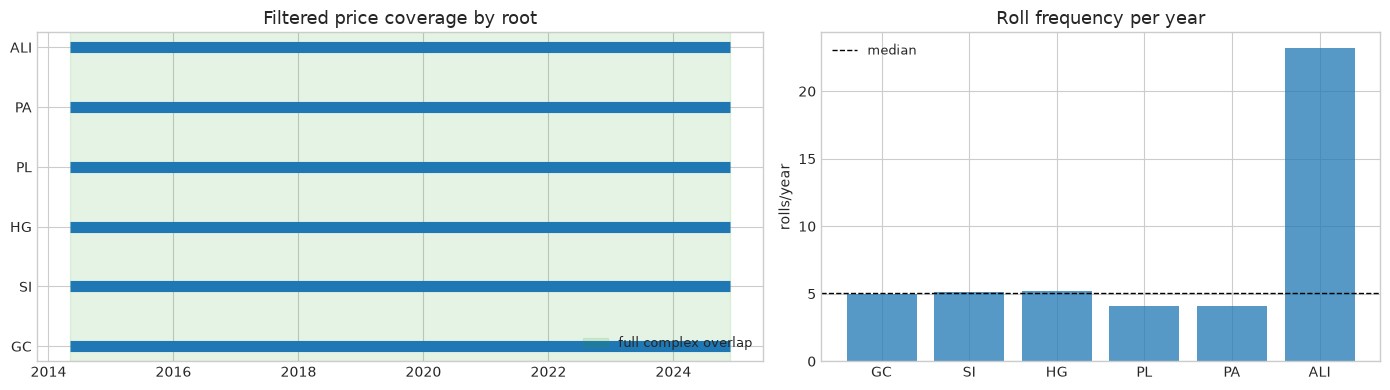

In [3]:
coverage_rows = []
for root, frame in continuous.items():
    filtered = frame.loc[frame.index >= START] if START is not None else frame
    price_dates = filtered.loc[filtered["cont_close"].notna()].index
    return_dates = filtered.loc[filtered["cont_logret"].notna()].index
    coverage_rows.append(
        {
            "root": root,
            "first_price": price_dates.min().date(),
            "last_price": price_dates.max().date(),
            "price_days": len(price_dates),
            "first_return": return_dates.min().date(),
            "last_return": return_dates.max().date(),
            "return_days": len(return_dates),
            "roll_days": int(filtered["is_roll"].fillna(False).sum()),
            "median_volume": float(filtered["volume"].median()),
        }
    )
coverage = pd.DataFrame(coverage_rows).set_index("root")

build_report = pd.read_csv(BUILD_REPORT_PATH).rename(
    columns={
        "rolls_per_yr": "rolls_per_year",
        "max_daily_move_%": "max_daily_abs_pct",
        "max_rollday_move_%": "max_roll_day_abs_pct",
        "span": "date_range",
    }
)
for column in [
    "rows",
    "contracts",
    "rolls",
    "rolls_per_year",
    "max_daily_abs_pct",
    "max_roll_day_abs_pct",
]:
    build_report[column] = pd.to_numeric(build_report[column], errors="coerce")
build_report = build_report[build_report["root"].isin(ROOTS)].set_index("root").loc[ROOTS]

overlap_summary = pd.DataFrame(
    {
        "metric": [
            "common_price_start",
            "common_price_end",
            "common_price_days",
            "common_return_start",
            "common_return_end",
            "common_return_days",
        ],
        "value": [
            common_price_idx.min().date(),
            common_price_idx.max().date(),
            len(common_price_idx),
            common_return_idx.min().date(),
            common_return_idx.max().date(),
            len(common_return_idx),
        ],
    }
).set_index("metric")

print("Common overlap")
display(overlap_summary)
print("Per-root filtered coverage")
display(coverage)
print("Continuous build report")
display(build_report)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), gridspec_kw={"width_ratios": [1.3, 1]})
for y, root in enumerate(ROOTS):
    first = pd.Timestamp(coverage.loc[root, "first_price"])
    last = pd.Timestamp(coverage.loc[root, "last_price"])
    axes[0].hlines(y, first, last, linewidth=8)
axes[0].axvspan(
    common_price_idx.min(),
    common_price_idx.max(),
    color="tab:green",
    alpha=0.12,
    label="full complex overlap",
)
axes[0].set_yticks(range(len(ROOTS)))
axes[0].set_yticklabels(ROOTS)
axes[0].set_title("Filtered price coverage by root")
axes[0].legend(loc="lower right")
axes[0].xaxis.set_major_locator(mdates.YearLocator(2))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

axes[1].bar(build_report.index, build_report["rolls_per_year"], color="tab:blue", alpha=0.75)
axes[1].set_title("Roll frequency per year")
axes[1].set_ylabel("rolls/year")
axes[1].axhline(
    build_report["rolls_per_year"].median(),
    color="black",
    linewidth=1,
    linestyle="--",
    label="median",
)
axes[1].legend()
fig.tight_layout()
plt.show()

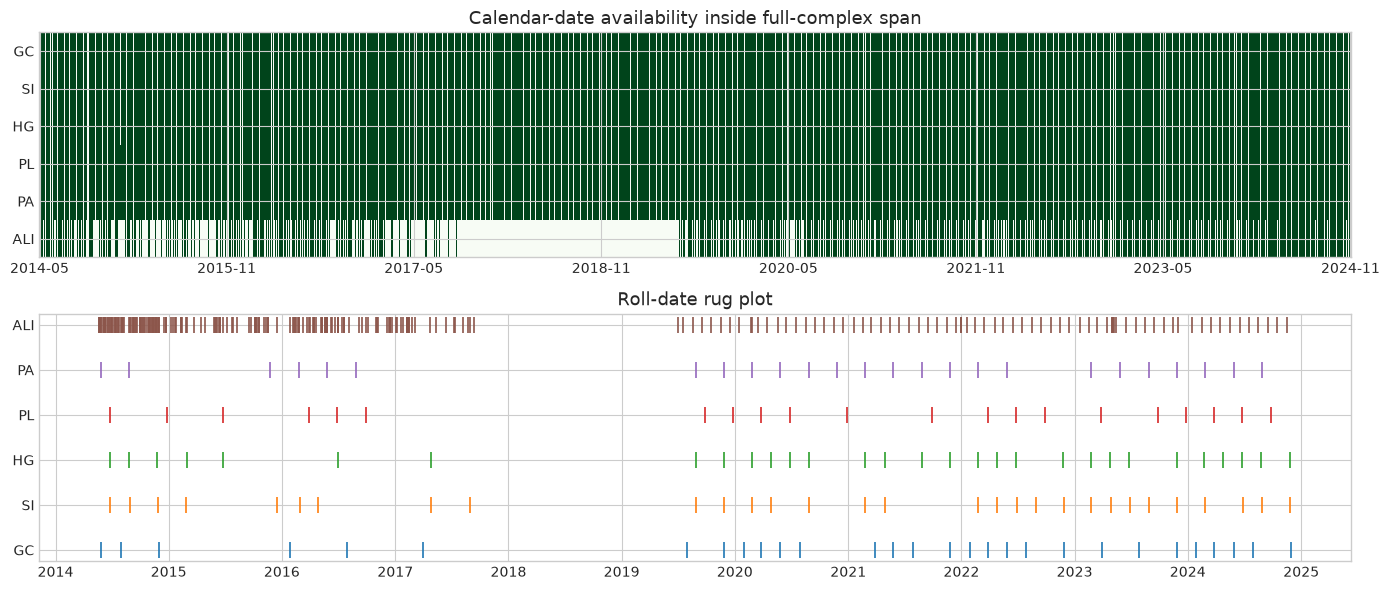

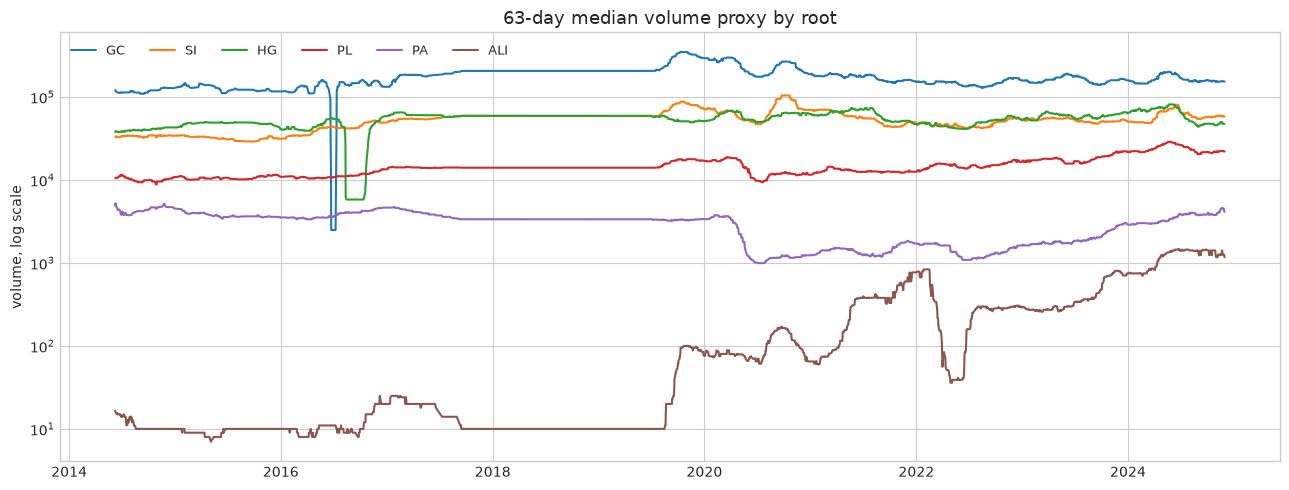

In [4]:
calendar_idx = pd.date_range(common_price_idx.min(), common_price_idx.max(), freq="D")
availability = price_panel.reindex(calendar_idx)[ROOTS].notna().T

fig, axes = plt.subplots(
    2, 1, figsize=(14, 6), sharex=False, gridspec_kw={"height_ratios": [1, 1.1]}
)
axes[0].imshow(availability.astype(int), aspect="auto", interpolation="nearest", cmap="Greens")
axes[0].set_yticks(range(len(ROOTS)))
axes[0].set_yticklabels(ROOTS)
axes[0].set_title("Calendar-date availability inside full-complex span")
locs = np.linspace(0, len(calendar_idx) - 1, 8, dtype=int)
axes[0].set_xticks(locs)
axes[0].set_xticklabels(calendar_idx[locs].strftime("%Y-%m"), rotation=0)

for y, root in enumerate(ROOTS):
    roll_dates = roll_common.index[roll_common[root].astype(bool)]
    axes[1].scatter(roll_dates, np.full(len(roll_dates), y), marker="|", s=130, linewidths=1.2)
axes[1].set_yticks(range(len(ROOTS)))
axes[1].set_yticklabels(ROOTS)
axes[1].set_title("Roll-date rug plot")
axes[1].xaxis.set_major_locator(mdates.YearLocator(1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
plt.show()

fig, axis = plt.subplots(figsize=(13, 5))
rolling_volume = volume_common[ROOTS].rolling(63, min_periods=20).median()
for root in ROOTS:
    axis.plot(rolling_volume.index, rolling_volume[root], label=root)
axis.set_yscale("log")
axis.set_title("63-day median volume proxy by root")
axis.set_ylabel("volume, log scale")
axis.legend(ncol=6, loc="upper left")
fig.tight_layout()
plt.show()

## Continuous Prices And Returns

These plots check whether the assets are moving on plausible scales and whether volatility regimes are materially different across the complex.

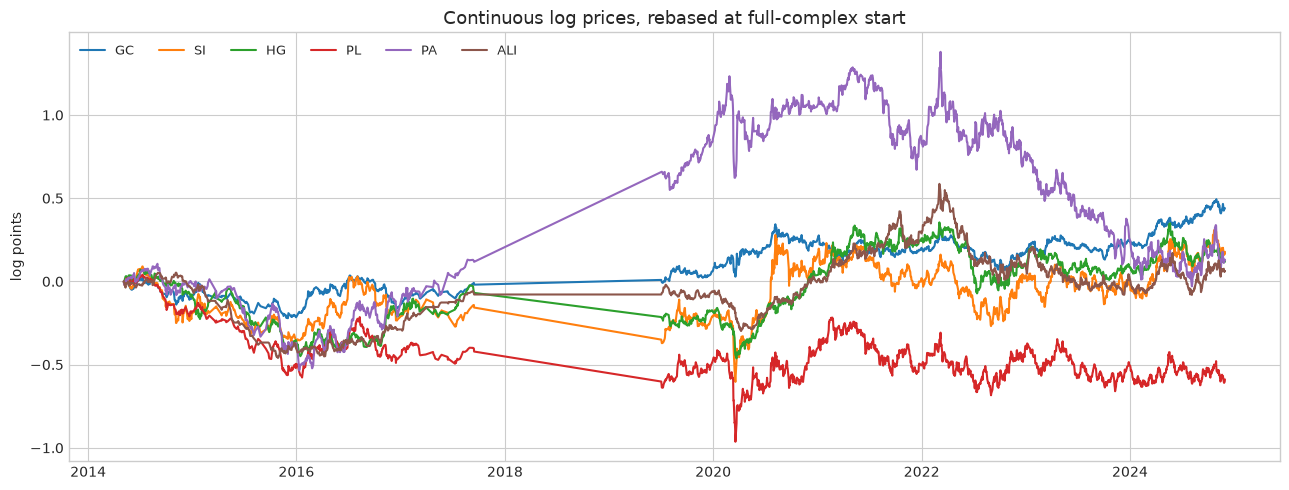

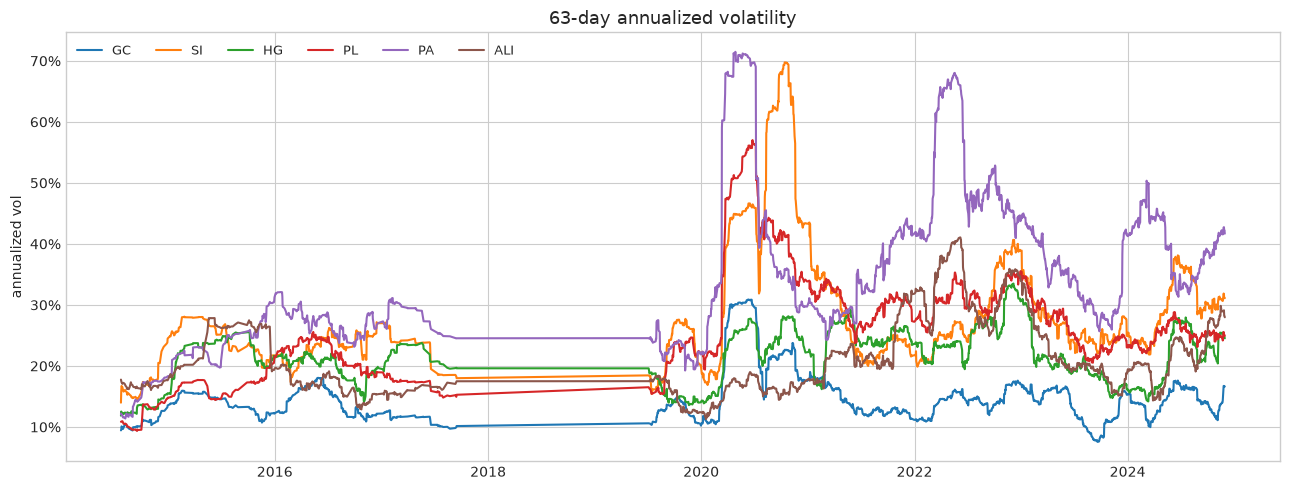

In [5]:
rebased_prices = price_common[ROOTS].sub(price_common[ROOTS].iloc[0], axis=1)

fig, axis = plt.subplots(figsize=(13, 5))
for root in ROOTS:
    axis.plot(rebased_prices.index, rebased_prices[root], label=root)
axis.set_title("Continuous log prices, rebased at full-complex start")
axis.set_ylabel("log points")
axis.legend(ncol=6, loc="upper left")
fig.tight_layout()
plt.show()

ann_vol = return_common[ROOTS].rolling(63, min_periods=30).std() * np.sqrt(252)
fig, axis = plt.subplots(figsize=(13, 5))
for root in ROOTS:
    axis.plot(ann_vol.index, ann_vol[root], label=root)
axis.set_title("63-day annualized volatility")
axis.set_ylabel("annualized vol")
axis.yaxis.set_major_formatter(lambda value, _pos: f"{value:.0%}")
axis.legend(ncol=6, loc="upper left")
fig.tight_layout()
plt.show()

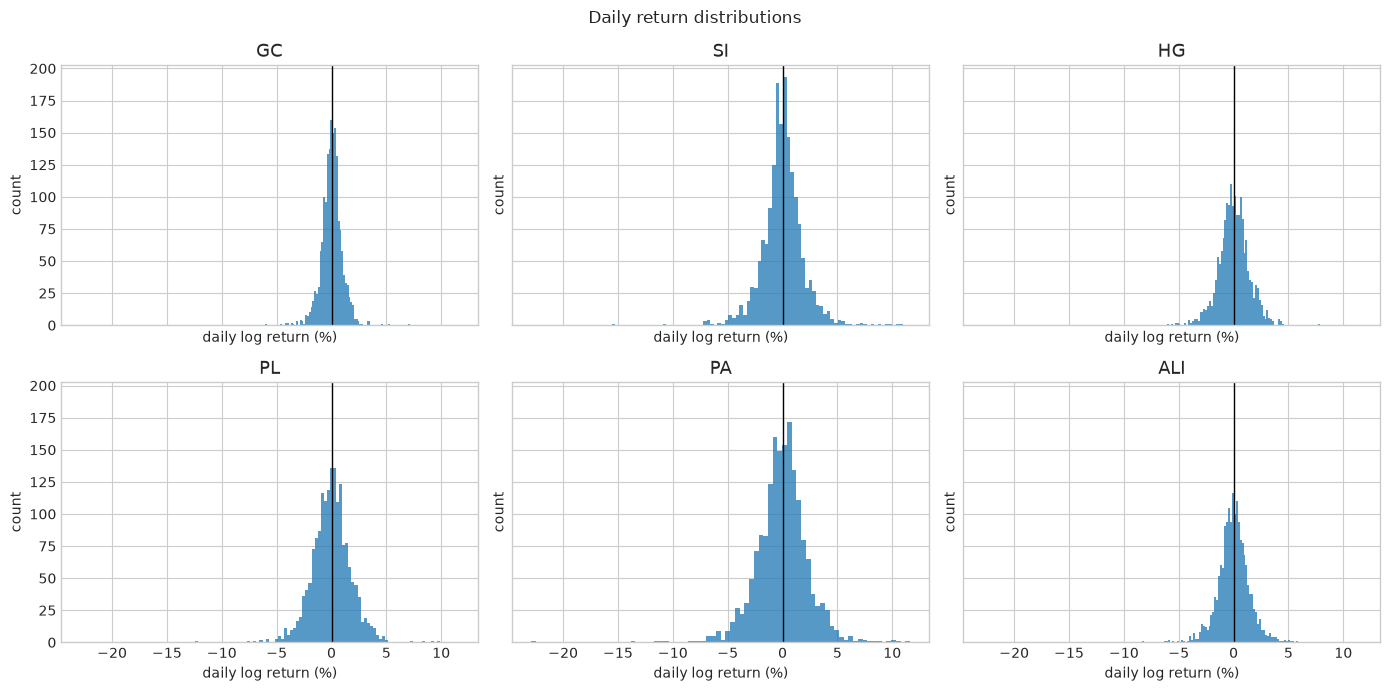

,mean_bps,vol_ann,skew,kurtosis,min_pct,max_pct
GC,1.385,0.152,-0.057,4.874,-6.021,7.152
SI,0.642,0.299,-0.063,6.402,-15.564,11.004
HG,1.464,0.220,-0.085,1.503,-6.058,7.867
PL,-2.114,0.278,-0.082,3.193,-12.429,9.910
PA,-4.961,0.376,-0.543,7.431,-22.897,11.616
ALI,0.359,0.224,-0.178,2.338,-8.305,5.864


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for axis, root in zip(axes.ravel(), ROOTS, strict=True):
    values = return_common[root].dropna() * 100
    axis.hist(values, bins=80, color="tab:blue", alpha=0.75)
    axis.axvline(0, color="black", linewidth=1)
    axis.set_title(root)
    axis.set_xlabel("daily log return (%)")
    axis.set_ylabel("count")
fig.suptitle("Daily return distributions")
fig.tight_layout()
plt.show()

return_stats = pd.DataFrame(
    {
        "mean_bps": return_common[ROOTS].mean() * 10_000,
        "vol_ann": return_common[ROOTS].std() * np.sqrt(252),
        "skew": return_common[ROOTS].skew(),
        "kurtosis": return_common[ROOTS].kurtosis(),
        "min_pct": return_common[ROOTS].min() * 100,
        "max_pct": return_common[ROOTS].max() * 100,
    }
).round(3)
display(return_stats)

## Residual Signal Diagnostics

The strategy fades each asset's residual versus the metals cross-sectional mean. These plots show the residual structure and the rolling z-scores that drive positions.

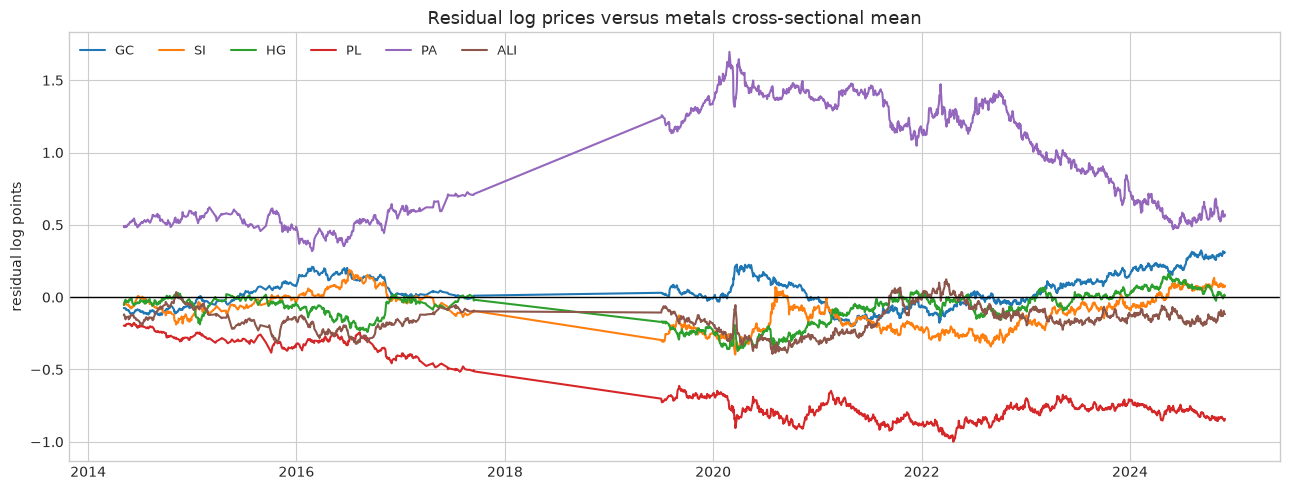

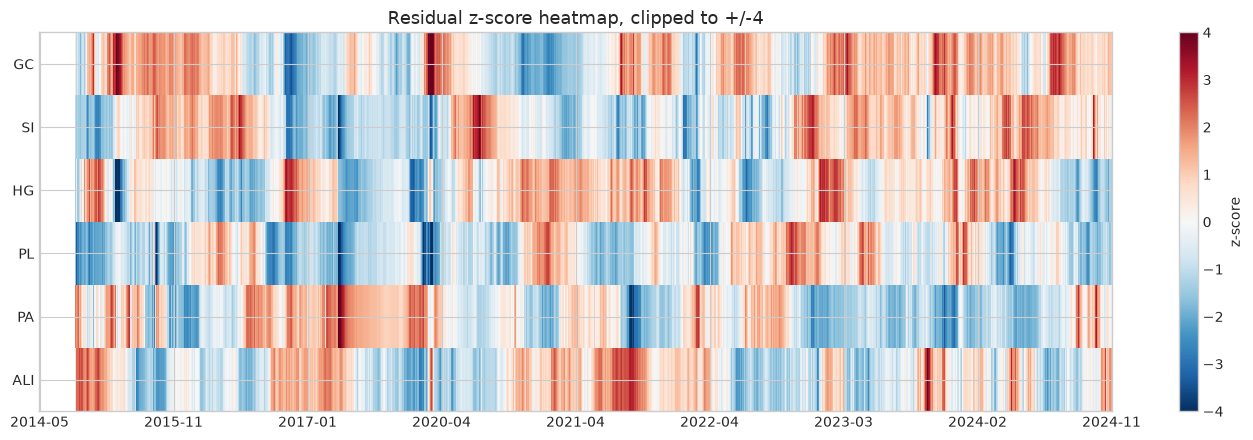

In [7]:
residuals = price_common[ROOTS].sub(price_common[ROOTS].mean(axis=1), axis=0)
rolling_mean = residuals.rolling(LOOKBACK, min_periods=LOOKBACK // 2).mean()
rolling_std = residuals.rolling(LOOKBACK, min_periods=LOOKBACK // 2).std()
zscores = (residuals - rolling_mean) / rolling_std
scores = -zscores.clip(-ENTRY_Z, ENTRY_Z) / ENTRY_Z

fig, axis = plt.subplots(figsize=(13, 5))
for root in ROOTS:
    axis.plot(residuals.index, residuals[root], label=root)
axis.axhline(0, color="black", linewidth=1)
axis.set_title("Residual log prices versus metals cross-sectional mean")
axis.set_ylabel("residual log points")
axis.legend(ncol=6, loc="upper left")
fig.tight_layout()
plt.show()

plot_z = zscores[ROOTS].clip(-4, 4).T
fig, axis = plt.subplots(figsize=(14, 4.5))
im = axis.imshow(plot_z, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-4, vmax=4)
axis.set_yticks(range(len(ROOTS)))
axis.set_yticklabels(ROOTS)
locs = np.linspace(0, len(plot_z.columns) - 1, 9, dtype=int)
axis.set_xticks(locs)
axis.set_xticklabels(plot_z.columns[locs].strftime("%Y-%m"), rotation=0)
axis.set_title("Residual z-score heatmap, clipped to +/-4")
fig.colorbar(im, ax=axis, label="z-score")
fig.tight_layout()
plt.show()

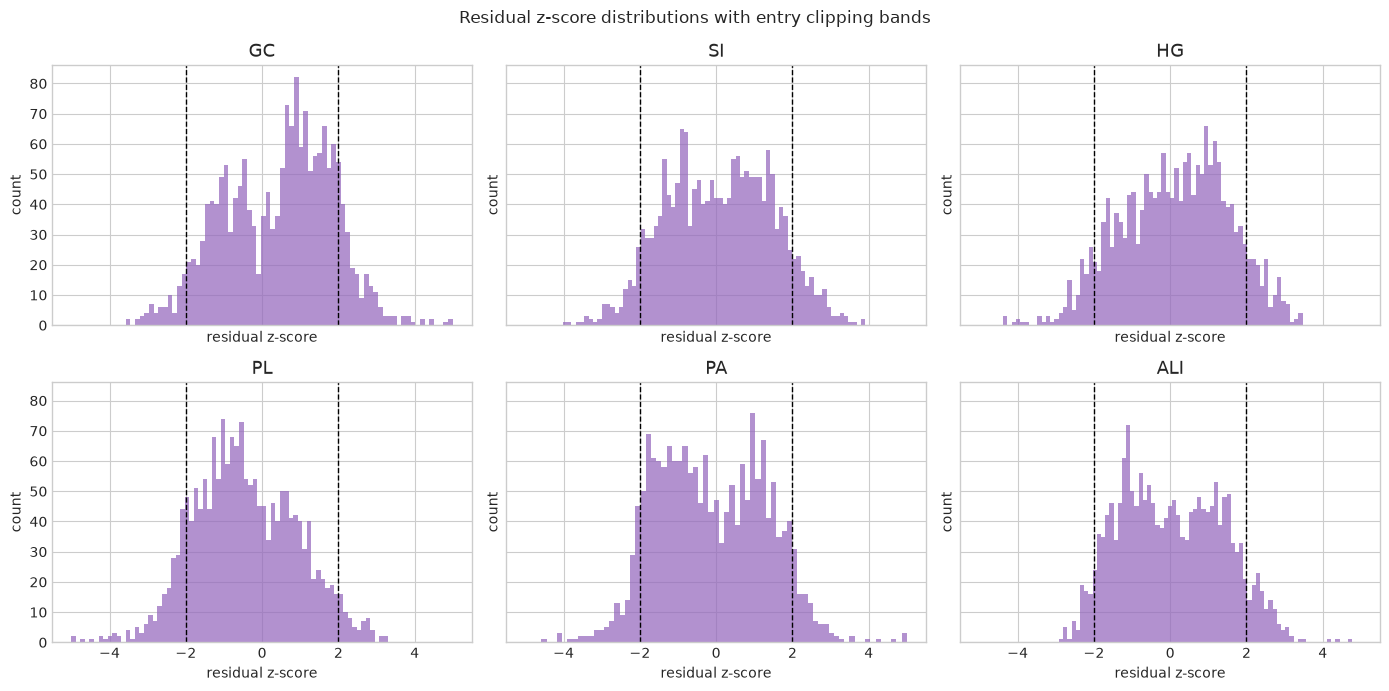

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for axis, root in zip(axes.ravel(), ROOTS, strict=True):
    values = zscores[root].dropna().clip(-5, 5)
    axis.hist(values, bins=70, color="tab:purple", alpha=0.72)
    axis.axvline(-ENTRY_Z, color="black", linewidth=1, linestyle="--")
    axis.axvline(ENTRY_Z, color="black", linewidth=1, linestyle="--")
    axis.set_title(root)
    axis.set_xlabel("residual z-score")
    axis.set_ylabel("count")
fig.suptitle("Residual z-score distributions with entry clipping bands")
fig.tight_layout()
plt.show()

## Positions, Turnover, And Cost Drag

The next plots show how the z-score signal becomes normalized daily exposure and where turnover/cost pressure appears.

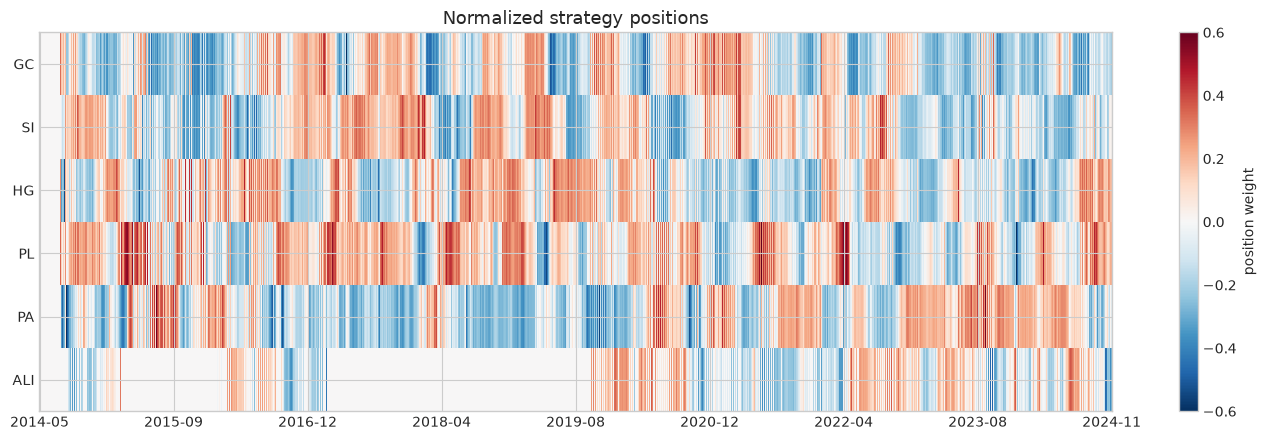

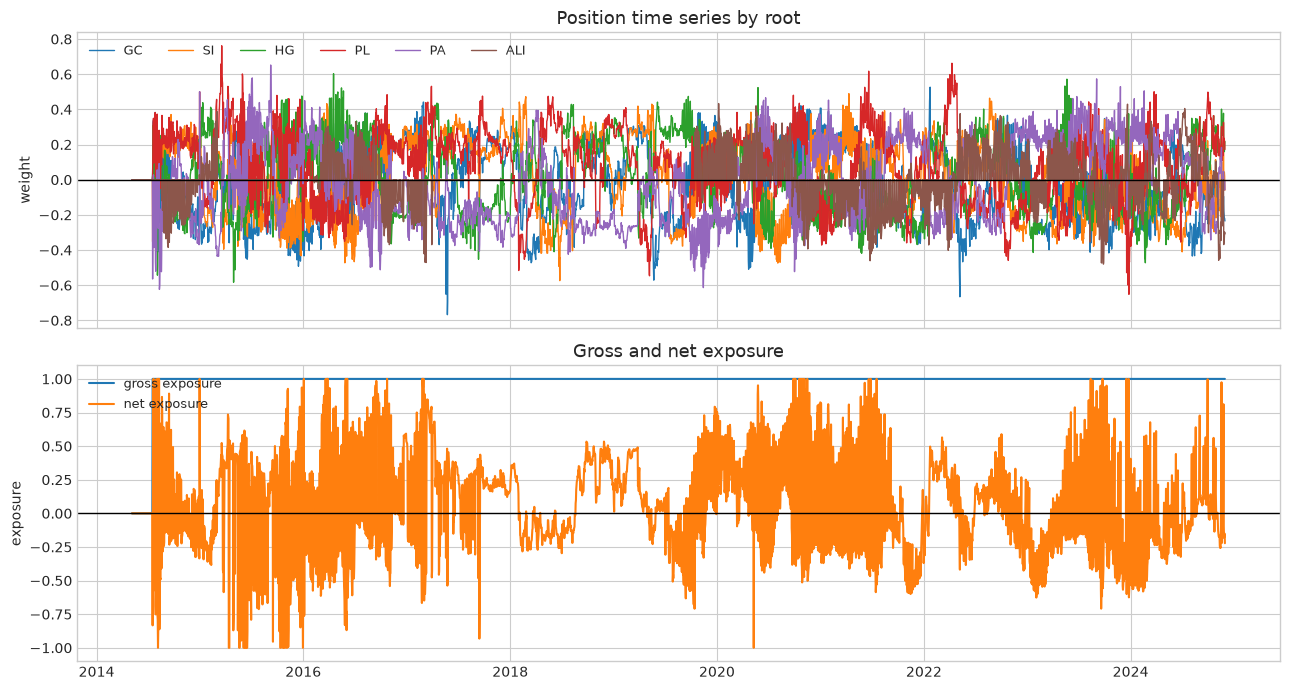

,GC,SI,HG,PL,PA,ALI
date,,,,,,
2024-11-19,-0.0830,-0.0930,0.2719,0.1476,-0.1413,-0.2633
2024-11-20,-0.1584,-0.0264,0.2525,0.1821,-0.1280,-0.2526
2024-11-21,-0.1524,0.0418,0.2642,0.1532,-0.1503,-0.2381
2024-11-22,-0.2313,-0.1099,0.2784,0.1366,-0.0485,-0.1954
2024-11-24,-0.0941,0.1548,0.3777,0.3259,0.0476,0.0000
2024-11-25,-0.1781,0.0212,0.1970,0.2164,0.0184,-0.3689
2024-11-26,-0.2028,-0.0571,0.1734,0.2355,-0.0200,-0.3112
2024-11-27,-0.2179,0.0425,0.1590,0.2237,-0.0246,-0.3322
2024-11-28,-0.2191,0.0205,0.1878,0.2164,-0.0587,-0.2976


In [9]:
plot_positions = positions[ROOTS].copy()
fig, axis = plt.subplots(figsize=(14, 4.5))
im = axis.imshow(
    plot_positions.T, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-0.6, vmax=0.6
)
axis.set_yticks(range(len(ROOTS)))
axis.set_yticklabels(ROOTS)
locs = np.linspace(0, len(plot_positions.index) - 1, 9, dtype=int)
axis.set_xticks(locs)
axis.set_xticklabels(plot_positions.index[locs].strftime("%Y-%m"), rotation=0)
axis.set_title("Normalized strategy positions")
fig.colorbar(im, ax=axis, label="position weight")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for root in ROOTS:
    axes[0].plot(plot_positions.index, plot_positions[root], label=root, linewidth=1)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Position time series by root")
axes[0].set_ylabel("weight")
axes[0].legend(ncol=6, loc="upper left")

gross_exposure = plot_positions.abs().sum(axis=1)
net_exposure = plot_positions.sum(axis=1)
axes[1].plot(gross_exposure.index, gross_exposure, label="gross exposure")
axes[1].plot(net_exposure.index, net_exposure, label="net exposure")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Gross and net exposure")
axes[1].set_ylabel("exposure")
axes[1].legend(loc="upper left")
fig.tight_layout()
plt.show()

latest_positions = plot_positions.tail(10)
display(latest_positions.round(4))

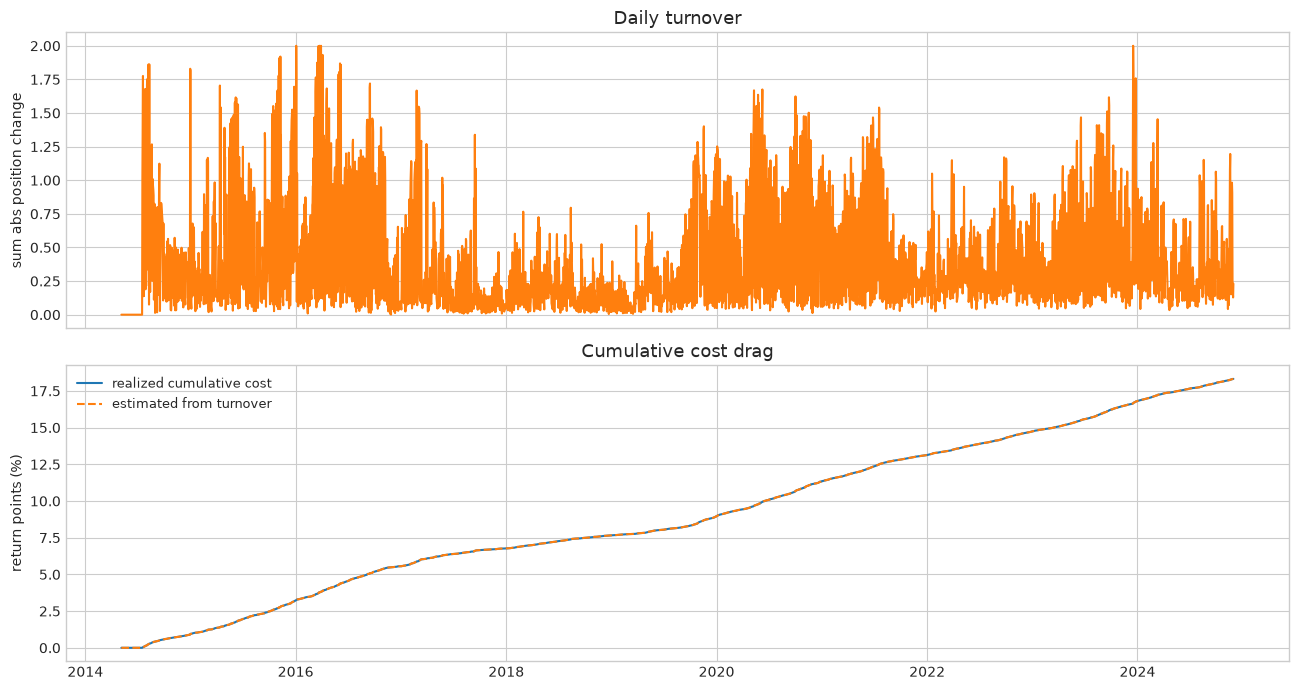

,turnover_mean,turnover_95pct,oos_cost_return
0,0.372519,1.065899,0.05504


In [10]:
turnover = plot_positions.diff().abs().sum(axis=1).fillna(plot_positions.abs().sum(axis=1))
estimated_cost = turnover * COST_BPS / 10_000
realized_cost = portfolio_returns["cost_return"].reindex(turnover.index).fillna(0.0)
oos_turnover = turnover.reindex(oos_returns.index)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(turnover.index, turnover, color="tab:orange")
axes[0].set_title("Daily turnover")
axes[0].set_ylabel("sum abs position change")
axes[1].plot(realized_cost.index, realized_cost.cumsum() * 100, label="realized cumulative cost")
axes[1].plot(
    estimated_cost.index,
    estimated_cost.cumsum() * 100,
    label="estimated from turnover",
    linestyle="--",
)
axes[1].set_title("Cumulative cost drag")
axes[1].set_ylabel("return points (%)")
axes[1].legend(loc="upper left")
fig.tight_layout()
plt.show()

display(
    pd.DataFrame(
        {
            "turnover_mean": [oos_turnover.mean()],
            "turnover_95pct": [oos_turnover.quantile(0.95)],
            "oos_cost_return": [oos_returns["cost_return"].sum()],
        }
    ).round(6)
)

## OOS Performance And Drawdowns

These are the core inspection plots for the realized HYP-0011 result.

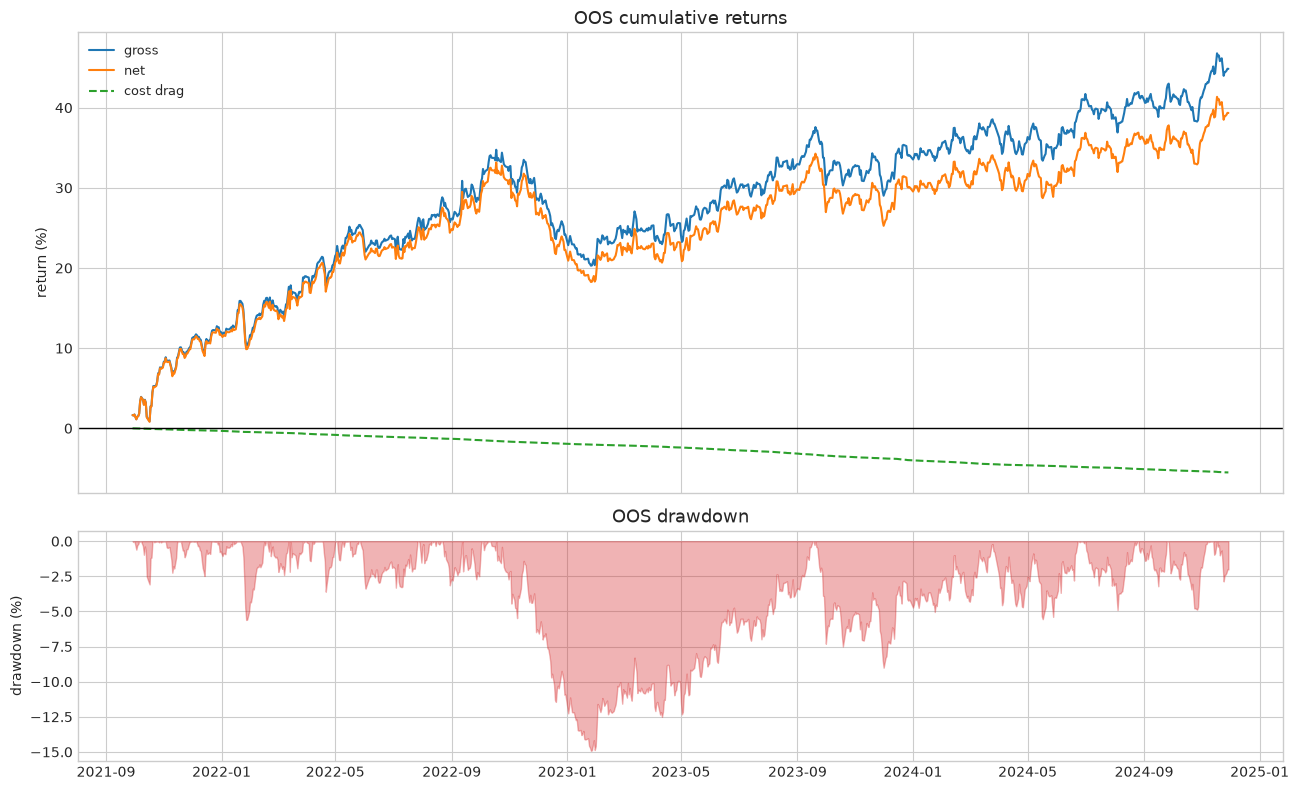

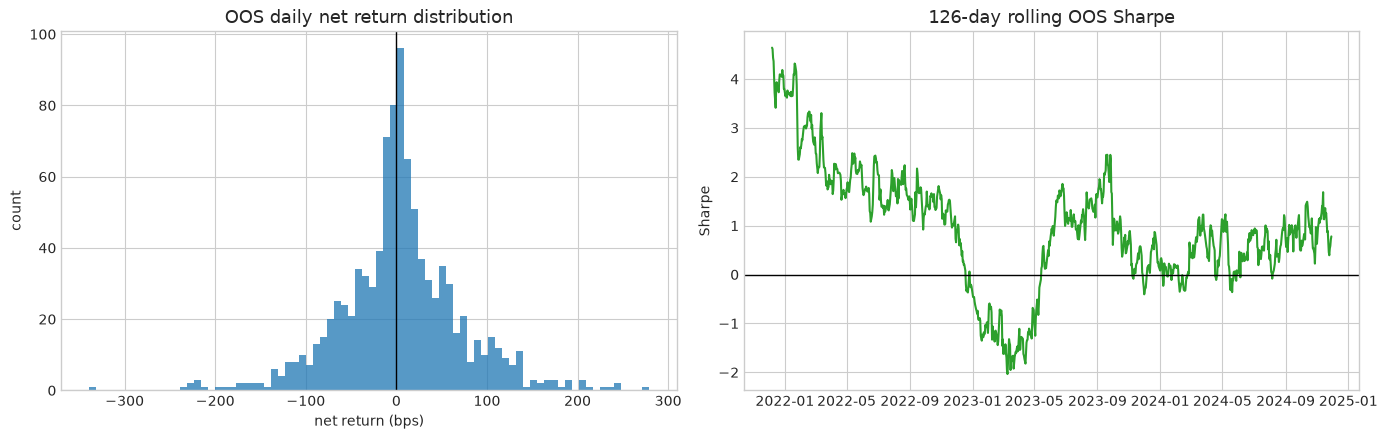

In [11]:
oos = oos_returns.copy()
oos["cum_gross"] = oos["gross_return"].cumsum()
oos["cum_cost"] = oos["cost_return"].cumsum()
oos["cum_net"] = oos["net_return"].cumsum()
oos["drawdown"] = oos["cum_net"] - oos["cum_net"].cummax()

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(oos.index, oos["cum_gross"] * 100, label="gross")
axes[0].plot(oos.index, oos["cum_net"] * 100, label="net")
axes[0].plot(oos.index, -oos["cum_cost"] * 100, label="cost drag", linestyle="--")
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("OOS cumulative returns")
axes[0].set_ylabel("return (%)")
axes[0].legend(loc="upper left")
axes[1].fill_between(oos.index, oos["drawdown"] * 100, 0, color="tab:red", alpha=0.35)
axes[1].set_title("OOS drawdown")
axes[1].set_ylabel("drawdown (%)")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].hist(oos["net_return"] * 10_000, bins=80, color="tab:blue", alpha=0.75)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("OOS daily net return distribution")
axes[0].set_xlabel("net return (bps)")
axes[0].set_ylabel("count")

rolling_mean = oos["net_return"].rolling(126, min_periods=60).mean()
rolling_std = oos["net_return"].rolling(126, min_periods=60).std()
rolling_sharpe = rolling_mean / rolling_std * np.sqrt(252)
axes[1].plot(rolling_sharpe.index, rolling_sharpe, color="tab:green")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("126-day rolling OOS Sharpe")
axes[1].set_ylabel("Sharpe")
fig.tight_layout()
plt.show()

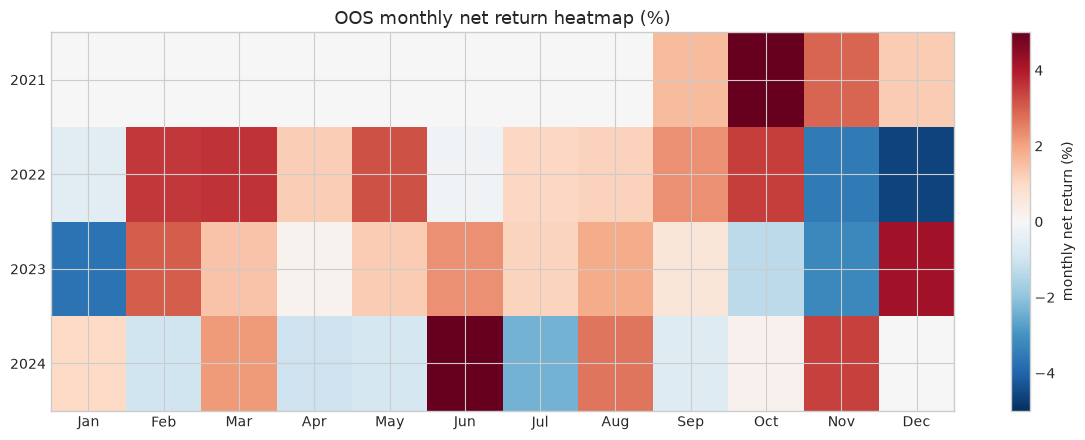

month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2021,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.59,5.97,2.89,1.27
2022,-0.56,3.52,3.61,1.23,3.19,-0.17,1.03,1.14,2.30,3.44,-3.55,-4.63
2023,-3.69,3.03,1.42,0.18,1.28,2.30,1.11,1.85,0.62,-1.32,-3.23,4.19
2024,1.01,-1.00,2.12,-1.03,-0.86,5.85,-2.38,2.66,-0.63,0.20,3.41,0.00


In [12]:
monthly = oos["net_return"].resample("ME").sum().to_frame("net_return")
monthly["year"] = monthly.index.year
monthly["month"] = monthly.index.month
monthly_matrix = monthly.pivot(index="year", columns="month", values="net_return").fillna(0.0) * 100

fig, axis = plt.subplots(figsize=(12, 4.5))
im = axis.imshow(
    monthly_matrix, aspect="auto", interpolation="nearest", cmap="RdBu_r", vmin=-5, vmax=5
)
axis.set_yticks(range(len(monthly_matrix.index)))
axis.set_yticklabels(monthly_matrix.index.astype(str))
axis.set_xticks(range(12))
axis.set_xticklabels(
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)
axis.set_title("OOS monthly net return heatmap (%)")
fig.colorbar(im, ax=axis, label="monthly net return (%)")
fig.tight_layout()
plt.show()

display(monthly_matrix.round(2))

## Asset Contributions And Signal Conditioning

These plots help identify whether the result is broad-based or concentrated, and whether the residual z-score has the expected mean-reversion shape.

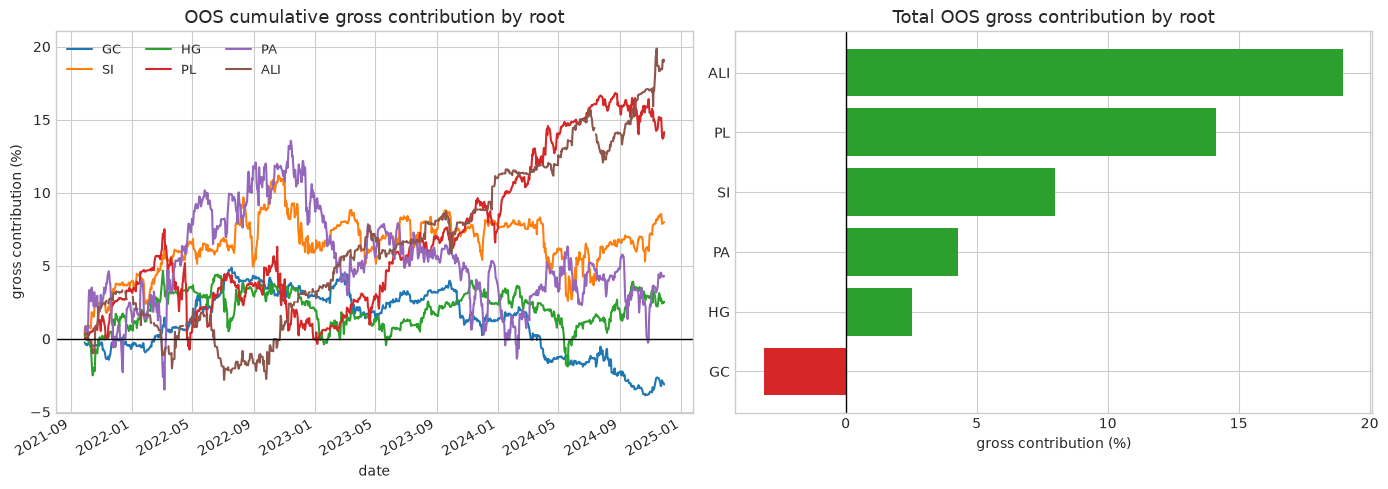

,gross_contribution_pct,mean_contribution_bps,hit_rate,share_abs_contribution
GC,-3.1195,-0.3170,0.5030,0.0948
SI,7.9918,0.8122,0.5254,0.1658
HG,2.5367,0.2578,0.4858,0.1410
PL,14.1527,1.4383,0.5437,0.1740
PA,4.2948,0.4365,0.4685,0.3077
ALI,18.9972,2.3541,0.3547,0.1167


In [13]:
forward_returns = return_panel[ROOTS].reindex(positions.index).shift(-1)
gross_contrib = positions[ROOTS] * forward_returns
contrib_oos = gross_contrib.reindex(oos.index).dropna(how="all")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
(contrib_oos.cumsum() * 100).plot(ax=axes[0])
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("OOS cumulative gross contribution by root")
axes[0].set_ylabel("gross contribution (%)")
axes[0].legend(ncol=3, loc="upper left")

total_contrib = contrib_oos.sum().sort_values()
axes[1].barh(
    total_contrib.index,
    total_contrib.values * 100,
    color=np.where(total_contrib.values >= 0, "tab:green", "tab:red"),
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Total OOS gross contribution by root")
axes[1].set_xlabel("gross contribution (%)")
fig.tight_layout()
plt.show()

contribution_summary = pd.DataFrame(
    {
        "gross_contribution_pct": contrib_oos.sum() * 100,
        "mean_contribution_bps": contrib_oos.mean() * 10_000,
        "hit_rate": (contrib_oos > 0).mean(),
        "share_abs_contribution": contrib_oos.abs().sum() / contrib_oos.abs().sum().sum(),
    }
).loc[ROOTS]
display(contribution_summary.round(4))

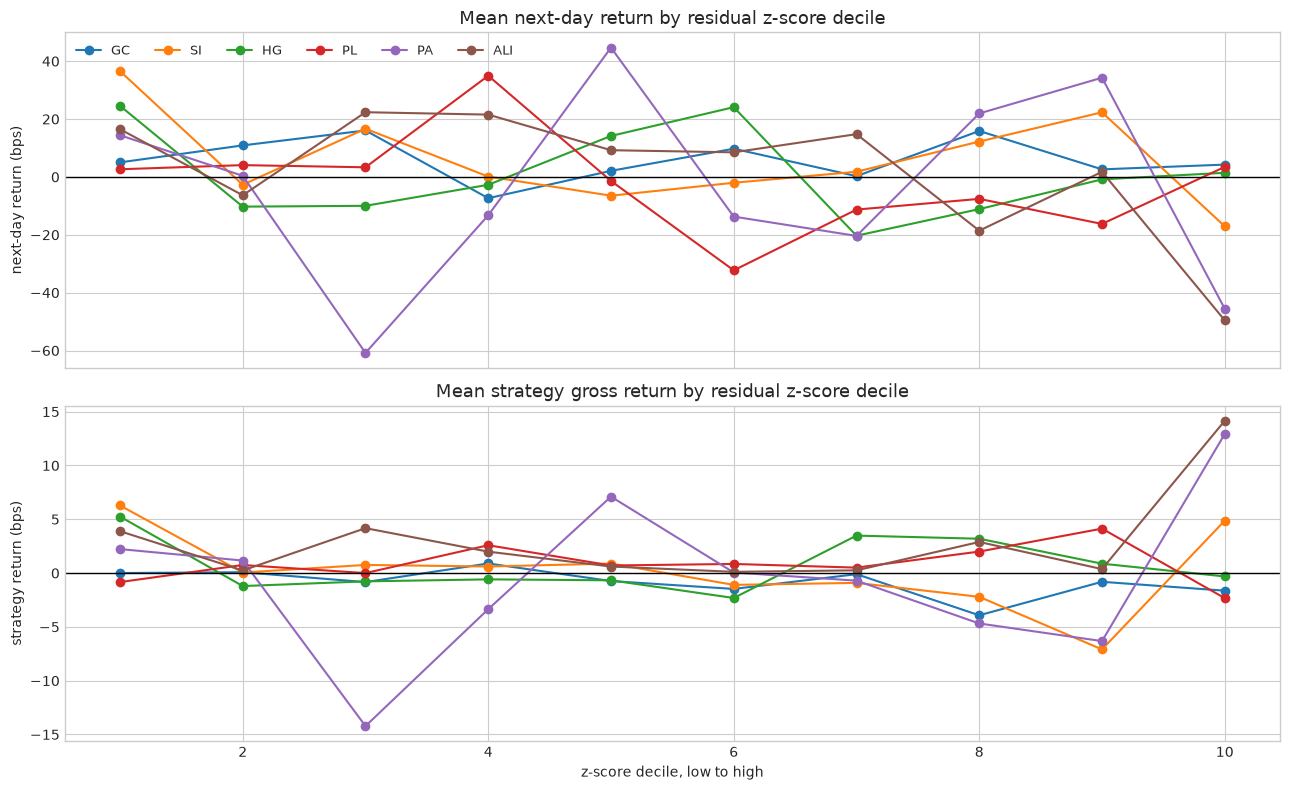

root,ALI,GC,HG,PA,PL,SI
z_decile,,,,,,
1,3.890,0.002,5.250,2.227,-0.838,6.281
2,0.242,0.079,-1.208,1.163,0.749,0.052
3,4.173,-0.838,-0.771,-14.222,-0.001,0.756
4,1.990,0.891,-0.586,-3.356,2.587,0.609
5,0.606,-0.743,-0.674,7.103,0.703,0.882
6,0.114,-1.474,-2.317,0.052,0.848,-1.098
7,0.253,-0.104,3.481,-0.704,0.505,-0.912
8,2.891,-3.923,3.191,-4.685,1.998,-2.209
9,0.372,-0.812,0.873,-6.323,4.132,-7.097


In [14]:
signal_rows = []
for root in ROOTS:
    frame = (
        pd.DataFrame(
            {
                "zscore": zscores[root],
                "forward_return": return_panel[root].shift(-1),
                "position": positions[root],
            }
        )
        .reindex(oos.index)
        .dropna()
    )
    if len(frame) < 20:
        continue
    frame["z_decile"] = pd.qcut(frame["zscore"], 10, labels=False, duplicates="drop") + 1
    decile_stats = frame.groupby("z_decile", observed=True).agg(
        mean_forward_bps=("forward_return", lambda value: value.mean() * 10_000),
        mean_strategy_bps=("position", lambda value: np.nan),
        observations=("forward_return", "size"),
    )
    strategy_by_decile = (
        frame.assign(strategy_return=frame["position"] * frame["forward_return"])
        .groupby("z_decile", observed=True)["strategy_return"]
        .mean()
        * 10_000
    )
    decile_stats["mean_strategy_bps"] = strategy_by_decile
    decile_stats["root"] = root
    signal_rows.append(decile_stats.reset_index())

signal_deciles = pd.concat(signal_rows, ignore_index=True)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
for root in ROOTS:
    root_stats = signal_deciles[signal_deciles["root"] == root]
    axes[0].plot(root_stats["z_decile"], root_stats["mean_forward_bps"], marker="o", label=root)
    axes[1].plot(root_stats["z_decile"], root_stats["mean_strategy_bps"], marker="o", label=root)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].set_title("Mean next-day return by residual z-score decile")
axes[0].set_ylabel("next-day return (bps)")
axes[0].legend(ncol=6, loc="upper left")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Mean strategy gross return by residual z-score decile")
axes[1].set_xlabel("z-score decile, low to high")
axes[1].set_ylabel("strategy return (bps)")
fig.tight_layout()
plt.show()

display(signal_deciles.pivot(index="z_decile", columns="root", values="mean_strategy_bps").round(3))

,slope_bps_per_z,tstat,corr,observations
root,,,,
GC,-2.0229,-0.7537,-0.0264,817
SI,-6.0481,-1.2819,-0.0449,817
HG,-2.2845,-0.6325,-0.0222,817
PL,-4.4412,-0.9985,-0.0350,817
PA,-2.7478,-0.3974,-0.0139,817
ALI,-12.1079,-2.3085,-0.0896,661


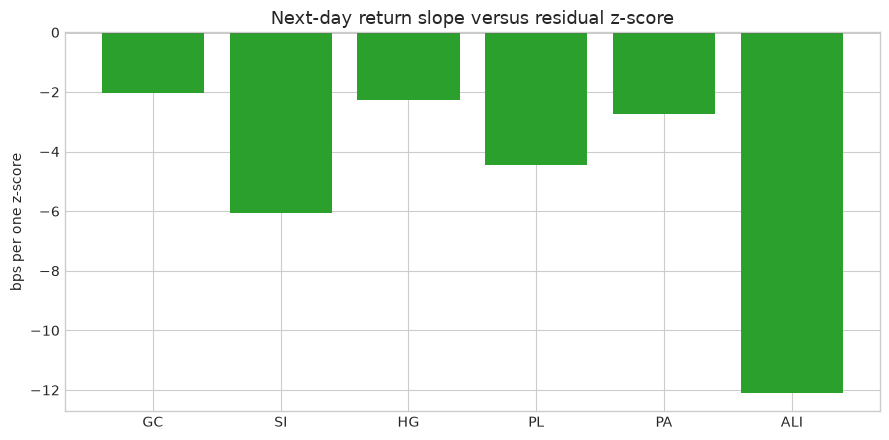

In [15]:
regression_rows = []
for root in ROOTS:
    frame = (
        pd.DataFrame(
            {
                "zscore": zscores[root],
                "forward_return": return_panel[root].shift(-1),
            }
        )
        .reindex(oos.index)
        .dropna()
    )
    x = frame["zscore"].to_numpy(dtype=float)
    y = frame["forward_return"].to_numpy(dtype=float)
    design = np.column_stack([np.ones(len(x)), x])
    beta = np.linalg.lstsq(design, y, rcond=None)[0]
    residual = y - design @ beta
    dof = len(x) - 2
    sigma_sq = float(residual @ residual / dof)
    cov = sigma_sq * np.linalg.inv(design.T @ design)
    se = float(np.sqrt(cov[1, 1]))
    regression_rows.append(
        {
            "root": root,
            "slope_bps_per_z": beta[1] * 10_000,
            "tstat": beta[1] / se if se > 0 else np.nan,
            "corr": np.corrcoef(x, y)[0, 1],
            "observations": len(frame),
        }
    )
regression_summary = pd.DataFrame(regression_rows).set_index("root")
display(regression_summary.round(4))

fig, axis = plt.subplots(figsize=(9, 4.5))
axis.bar(
    regression_summary.index,
    regression_summary["slope_bps_per_z"],
    color=np.where(regression_summary["slope_bps_per_z"] < 0, "tab:green", "tab:red"),
)
axis.axhline(0, color="black", linewidth=1)
axis.set_title("Next-day return slope versus residual z-score")
axis.set_ylabel("bps per one z-score")
fig.tight_layout()
plt.show()

## Drawdown-Control Variant Visuals

These plots compare the baseline strategy against the drawdown-control candidates generated in the HYP-0011 variant scan. The goal is to separate true drawdown improvement from simple exposure reduction or OOS-only overfit.

In [16]:
VARIANT_SCAN_PATH = EXPERIMENT_DIR / "drawdown_variant_scan.csv"
SELECTED_METRICS_PATH = EXPERIMENT_DIR / "drawdown_control_selected_metrics.csv"
SELECTED_RETURNS_PATH = EXPERIMENT_DIR / "drawdown_control_selected_returns.csv"

variant_scan = pd.read_csv(VARIANT_SCAN_PATH)
selected_metrics = pd.read_csv(SELECTED_METRICS_PATH).set_index("variant")
selected_returns = pd.read_csv(SELECTED_RETURNS_PATH, parse_dates=["date"]).set_index("date")

variant_order = [
    "baseline_all",
    "conservative_GC_SI_HG_PL",
    "vol_target_8pct_126d_GC_SI_HG_PL",
    "market_vol_filter_42d_p70_scale50_GC_SI_HG_PL",
    "deadband_0p5_GC_SI_HG_PL",
]
variant_labels = {
    "baseline_all": "Baseline: GC/SI/HG/PL/PA/ALI",
    "conservative_GC_SI_HG_PL": "Core: GC/SI/HG/PL",
    "vol_target_8pct_126d_GC_SI_HG_PL": "Core + 8% vol target",
    "market_vol_filter_42d_p70_scale50_GC_SI_HG_PL": "Core + high-vol 50% scale",
    "deadband_0p5_GC_SI_HG_PL": "Core + 0.5 z deadband",
}
variant_colors = dict(zip(variant_order, plt.cm.tab10.colors[: len(variant_order)], strict=True))

selected_metrics = selected_metrics.loc[variant_order]
metrics_display = selected_metrics[
    [
        "cagr",
        "compounded_return",
        "tstat",
        "sharpe",
        "max_drawdown_log",
        "calmar",
        "cost_log",
    ]
].copy()
for column in ["cagr", "compounded_return", "max_drawdown_log", "cost_log"]:
    metrics_display[column] = metrics_display[column].map(lambda value: f"{value:.2%}")
for column in ["tstat", "sharpe", "calmar"]:
    metrics_display[column] = metrics_display[column].map(lambda value: f"{value:.2f}")
metrics_display.index = [variant_labels[idx] for idx in metrics_display.index]
display(metrics_display)

,cagr,compounded_return,tstat,sharpe,max_drawdown_log,calmar,cost_log
Baseline: GC/SI/HG/PL/PA/ALI,13.23%,48.22%,1.85,0.94,-14.92%,0.89,5.50%
Core: GC/SI/HG/PL,13.87%,50.88%,2.23,1.13,-7.25%,1.91,3.34%
Core + 8% vol target,12.32%,44.51%,2.30,1.16,-6.41%,1.92,2.94%
Core + high-vol 50% scale,10.51%,37.23%,2.49,1.26,-5.00%,2.10,2.50%
Core + 0.5 z deadband,19.15%,74.22%,2.74,1.39,-8.14%,2.35,4.02%


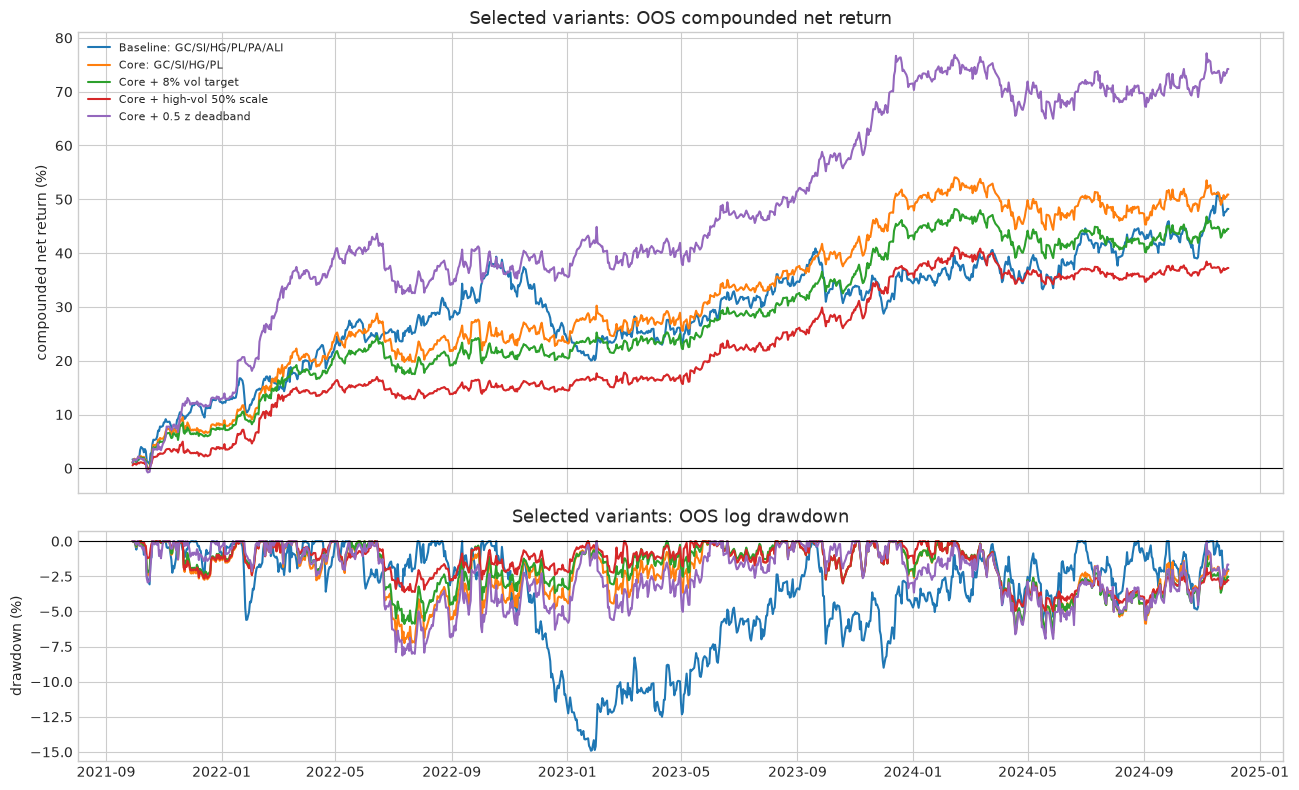

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
for variant in variant_order:
    frame = selected_returns[selected_returns["variant"] == variant].sort_index()
    cum_log = frame["net_return"].cumsum()
    compounded = np.exp(cum_log) - 1.0
    drawdown = cum_log - cum_log.cummax()
    axes[0].plot(
        frame.index, compounded * 100, label=variant_labels[variant], color=variant_colors[variant]
    )
    axes[1].plot(
        frame.index, drawdown * 100, label=variant_labels[variant], color=variant_colors[variant]
    )
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Selected variants: OOS compounded net return")
axes[0].set_ylabel("compounded net return (%)")
axes[0].legend(loc="upper left", fontsize=8)
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Selected variants: OOS log drawdown")
axes[1].set_ylabel("drawdown (%)")
fig.tight_layout()
plt.show()

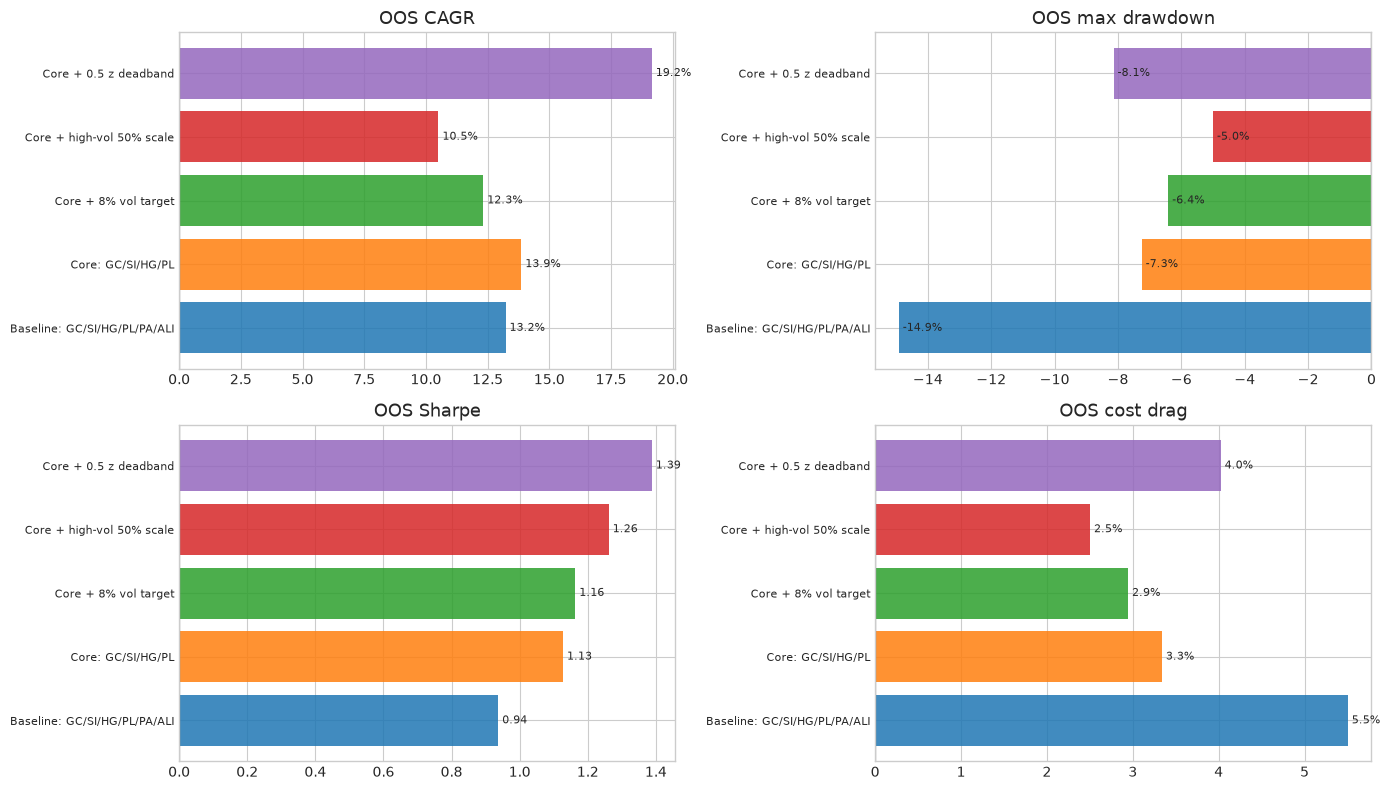

In [18]:
bar_frame = selected_metrics.copy()
bar_frame["label"] = [variant_labels[idx] for idx in bar_frame.index]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()
plots = [
    ("cagr", "OOS CAGR", lambda value: value * 100, "%"),
    ("max_drawdown_log", "OOS max drawdown", lambda value: value * 100, "%"),
    ("sharpe", "OOS Sharpe", lambda value: value, ""),
    ("cost_log", "OOS cost drag", lambda value: value * 100, "%"),
]
for axis, (column, title, transform, suffix) in zip(axes, plots, strict=True):
    values = bar_frame[column].map(transform)
    colors = [variant_colors[idx] for idx in bar_frame.index]
    axis.barh(bar_frame["label"], values, color=colors, alpha=0.85)
    axis.axvline(0, color="black", linewidth=0.8)
    axis.set_title(title)
    axis.tick_params(axis="y", labelsize=8)
    for y, value in enumerate(values):
        if suffix:
            text = f"{value:.1f}{suffix}"
        else:
            text = f"{value:.2f}"
        axis.text(value, y, f" {text}", va="center", fontsize=8)
fig.tight_layout()
plt.show()

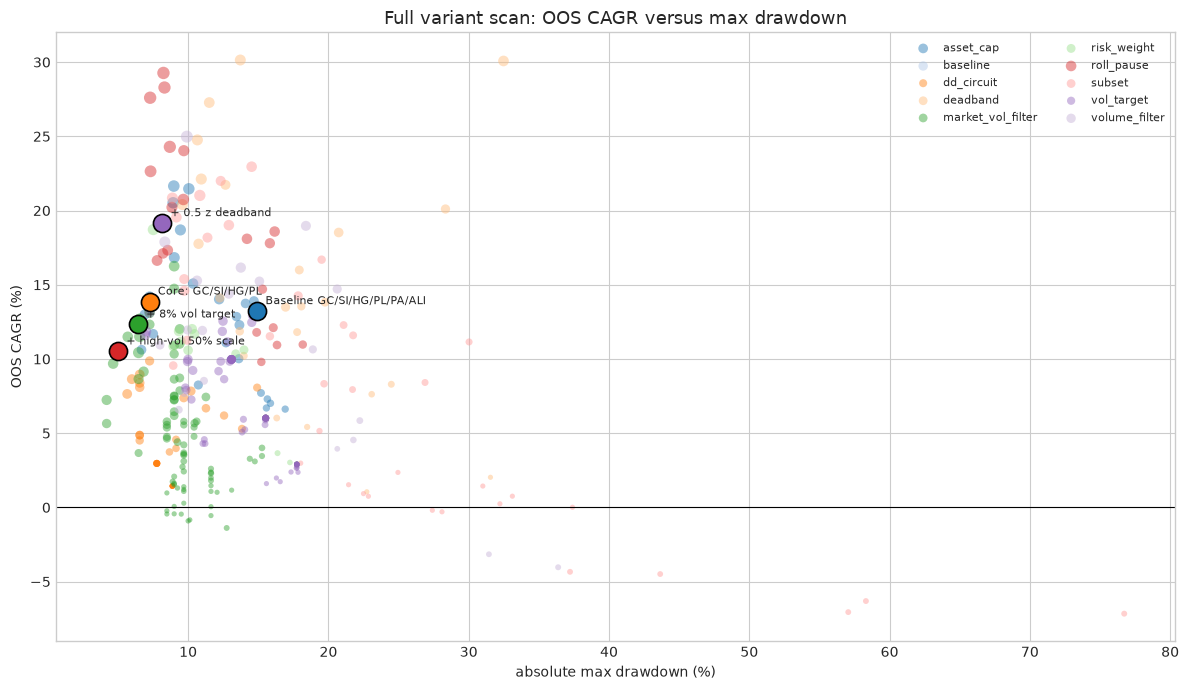

In [19]:
scan = (
    variant_scan.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["oos_cagr", "oos_mdd_log", "oos_tstat", "oos_calmar"])
    .copy()
)
scan["drawdown_abs"] = -scan["oos_mdd_log"]
scan["positive_oos"] = scan["oos_cagr"] > 0

family_order = sorted(scan["family"].dropna().unique())
family_colors = dict(zip(family_order, plt.cm.tab20.colors[: len(family_order)], strict=False))

fig, axis = plt.subplots(figsize=(12, 7))
for family in family_order:
    family_frame = scan[scan["family"] == family]
    axis.scatter(
        family_frame["drawdown_abs"] * 100,
        family_frame["oos_cagr"] * 100,
        s=np.clip((family_frame["oos_tstat"].fillna(0).abs() + 0.25) * 22, 14, 95),
        alpha=0.45,
        label=family,
        color=family_colors[family],
        edgecolor="none",
    )
for variant in variant_order:
    if variant == "conservative_GC_SI_HG_PL":
        label = "subset_GC_SI_HG_PL"
    elif variant == "vol_target_8pct_126d_GC_SI_HG_PL":
        label = "vol_target_noALI_noPA_base_w126_t0.08"
    elif variant == "market_vol_filter_42d_p70_scale50_GC_SI_HG_PL":
        label = "market_vol_filter_noALI_noPA_base_w42_p0.7_s0.5"
    elif variant == "deadband_0p5_GC_SI_HG_PL":
        label = "deadband_0.5_GC_SI_HG_PL"
    else:
        label = "baseline_all"
    row = scan.loc[scan["label"] == label].head(1)
    if row.empty:
        continue
    axis.scatter(
        -row["oos_mdd_log"].iloc[0] * 100,
        row["oos_cagr"].iloc[0] * 100,
        s=170,
        color=variant_colors[variant],
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )
    axis.annotate(
        variant_labels[variant].replace("Baseline: ", "Baseline ").replace("Core + ", "+ "),
        (-row["oos_mdd_log"].iloc[0] * 100, row["oos_cagr"].iloc[0] * 100),
        xytext=(6, 5),
        textcoords="offset points",
        fontsize=8,
    )
axis.axhline(0, color="black", linewidth=0.8)
axis.set_title("Full variant scan: OOS CAGR versus max drawdown")
axis.set_xlabel("absolute max drawdown (%)")
axis.set_ylabel("OOS CAGR (%)")
axis.legend(loc="upper right", fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

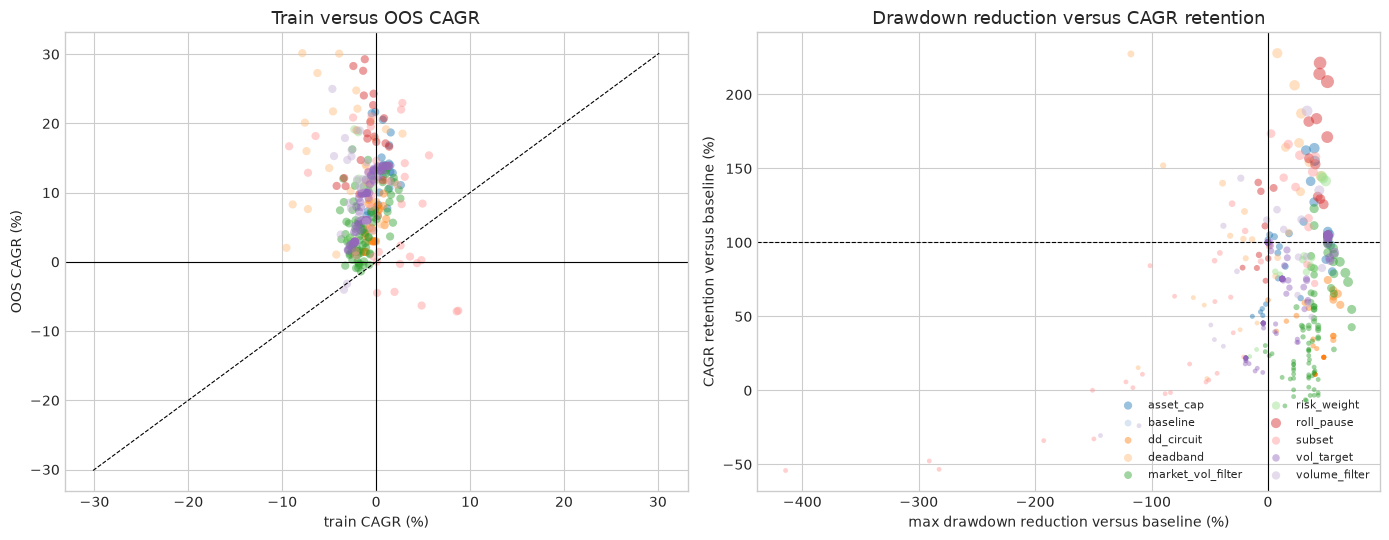

In [20]:
baseline_scan = scan.loc[scan["label"] == "baseline_all"].iloc[0]
robust = scan.copy()
robust["mdd_reduction"] = 1.0 - robust["drawdown_abs"] / (-baseline_scan["oos_mdd_log"])
robust["cagr_retention"] = robust["oos_cagr"] / baseline_scan["oos_cagr"]
robust["train_oos_cagr_gap"] = robust["oos_cagr"] - robust["train_cagr"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for family in family_order:
    family_frame = robust[robust["family"] == family]
    axes[0].scatter(
        family_frame["train_cagr"] * 100,
        family_frame["oos_cagr"] * 100,
        alpha=0.45,
        s=35,
        color=family_colors[family],
        label=family,
        edgecolor="none",
    )
limit = np.nanmax(np.abs(pd.concat([robust["train_cagr"], robust["oos_cagr"]]))) * 100
axes[0].plot([-limit, limit], [-limit, limit], color="black", linewidth=0.8, linestyle="--")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].axvline(0, color="black", linewidth=0.8)
axes[0].set_title("Train versus OOS CAGR")
axes[0].set_xlabel("train CAGR (%)")
axes[0].set_ylabel("OOS CAGR (%)")

for family in family_order:
    family_frame = robust[robust["family"] == family]
    axes[1].scatter(
        family_frame["mdd_reduction"] * 100,
        family_frame["cagr_retention"] * 100,
        alpha=0.45,
        s=np.clip((family_frame["oos_calmar"].fillna(0).clip(lower=0) + 0.2) * 22, 12, 120),
        color=family_colors[family],
        label=family,
        edgecolor="none",
    )
axes[1].axhline(100, color="black", linewidth=0.8, linestyle="--")
axes[1].axvline(0, color="black", linewidth=0.8)
axes[1].set_title("Drawdown reduction versus CAGR retention")
axes[1].set_xlabel("max drawdown reduction versus baseline (%)")
axes[1].set_ylabel("CAGR retention versus baseline (%)")
axes[1].legend(loc="lower right", fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

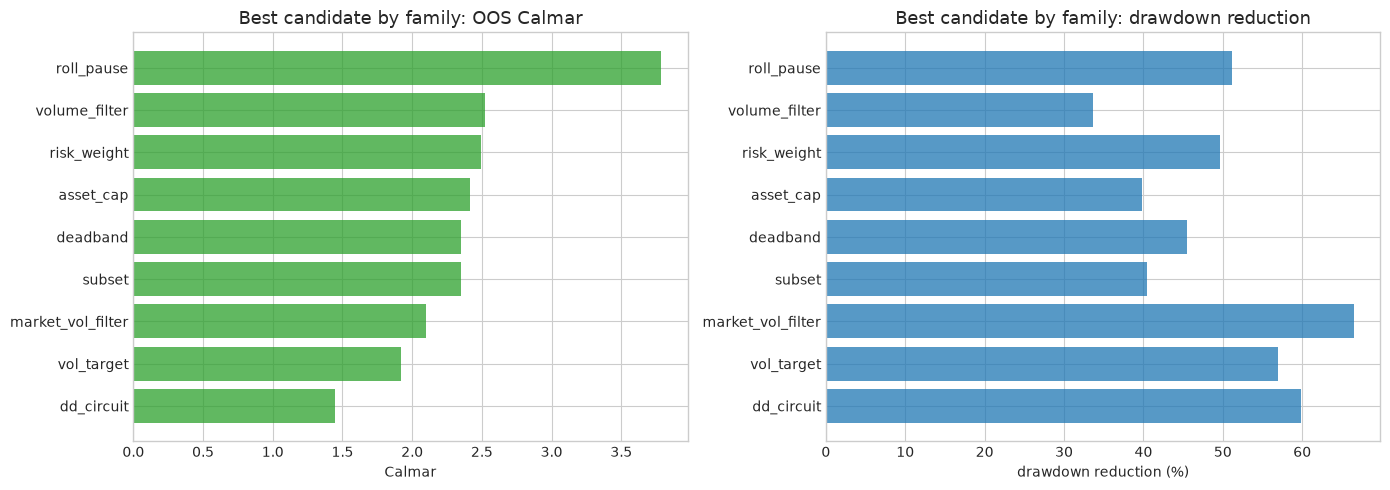

,family,label,roots,params,oos_cagr,oos_tstat,oos_mdd_log,oos_calmar,train_cagr
363,dd_circuit,dd_circuit_noALI_noPA_base_dd0.05_s0.5,"GC,SI,HG,PL",base=noALI_noPA_base;dd=0.05;scale=0.5,8.64%,2.06,-5.99%,1.44,0.01%
337,vol_target,vol_target_noALI_noPA_base_w126_t0.08,"GC,SI,HG,PL",base=noALI_noPA_base;w=126;target=0.08;cap=1,12.32%,2.30,-6.41%,1.92,0.21%
343,market_vol_filter,market_vol_filter_noALI_noPA_base_w42_p0.7_s0.5,"GC,SI,HG,PL",base=noALI_noPA_base;w=42;p=0.7;scale=0.5;thr=...,10.51%,2.49,-5.00%,2.10,1.29%
7,subset,subset_GC_HG_ALI,"GC,HG,ALI",NaN,20.84%,2.65,-8.88%,2.35,-2.45%
92,deadband,deadband_0.5_GC_SI_HG_PL,"GC,SI,HG,PL",deadband=0.5,19.15%,2.74,-8.14%,2.35,1.05%
132,asset_cap,asset_cap_0.4_GC_SI_HG_PL_ALI,"GC,SI,HG,PL,ALI",cap=0.4,21.65%,2.92,-8.98%,2.41,-0.09%
126,risk_weight,inv_vol_signal_w63_GC_SI_HG_PL_ALI,"GC,SI,HG,PL,ALI",volw=63,18.72%,2.71,-7.52%,2.49,-1.90%
143,volume_filter,volume_filter_q0.05_GC_SI_HG_PL_ALI,"GC,SI,HG,PL,ALI",q=0.05,24.98%,3.12,-9.91%,2.52,-4.66%
139,roll_pause,roll_pause_1_GC_SI_HG_PL_ALI,"GC,SI,HG,PL,ALI",pause=1,27.60%,3.37,-7.29%,3.79,-1.38%


In [21]:
family_best = (
    robust[(robust["oos_cagr"] > 0) & (robust["mdd_reduction"] > 0)]
    .assign(
        score=lambda frame: frame["mdd_reduction"]
        + 0.35 * frame["cagr_retention"]
        + 0.15 * frame["oos_calmar"]
    )
    .sort_values("score", ascending=False)
    .groupby("family", as_index=False)
    .head(1)
    .sort_values("oos_calmar", ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].barh(family_best["family"], family_best["oos_calmar"], color="tab:green", alpha=0.75)
axes[0].set_title("Best candidate by family: OOS Calmar")
axes[0].set_xlabel("Calmar")
axes[1].barh(
    family_best["family"], family_best["mdd_reduction"] * 100, color="tab:blue", alpha=0.75
)
axes[1].set_title("Best candidate by family: drawdown reduction")
axes[1].set_xlabel("drawdown reduction (%)")
fig.tight_layout()
plt.show()

display(
    family_best[
        [
            "family",
            "label",
            "roots",
            "params",
            "oos_cagr",
            "oos_tstat",
            "oos_mdd_log",
            "oos_calmar",
            "train_cagr",
        ]
    ].assign(
        oos_cagr=lambda frame: frame["oos_cagr"].map(lambda value: f"{value:.2%}"),
        oos_mdd_log=lambda frame: frame["oos_mdd_log"].map(lambda value: f"{value:.2%}"),
        train_cagr=lambda frame: frame["train_cagr"].map(lambda value: f"{value:.2%}"),
        oos_tstat=lambda frame: frame["oos_tstat"].map(lambda value: f"{value:.2f}"),
        oos_calmar=lambda frame: frame["oos_calmar"].map(lambda value: f"{value:.2f}"),
    )
)

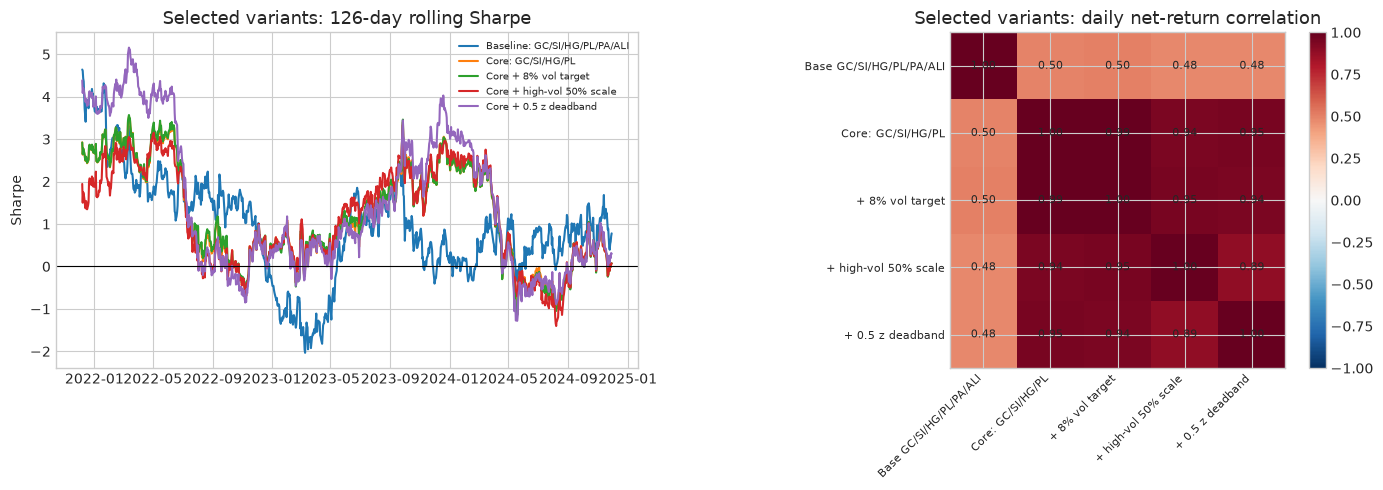

In [22]:
variant_net = selected_returns.pivot_table(
    index=selected_returns.index,
    columns="variant",
    values="net_return",
    aggfunc="sum",
).loc[:, variant_order]
variant_net.columns = [variant_labels[column] for column in variant_net.columns]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
rolling_sharpe = (
    variant_net.rolling(126, min_periods=60).mean()
    / variant_net.rolling(126, min_periods=60).std()
    * np.sqrt(252)
)
for column in rolling_sharpe.columns:
    axes[0].plot(rolling_sharpe.index, rolling_sharpe[column], label=column)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("Selected variants: 126-day rolling Sharpe")
axes[0].set_ylabel("Sharpe")
axes[0].legend(fontsize=7)

corr = variant_net.corr()
im = axes[1].imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
axes[1].set_title("Selected variants: daily net-return correlation")
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_yticks(range(len(corr.index)))
axes[1].set_xticklabels(
    [label.replace("Core + ", "+ ").replace("Baseline: ", "Base ") for label in corr.columns],
    rotation=45,
    ha="right",
    fontsize=8,
)
axes[1].set_yticklabels(
    [label.replace("Core + ", "+ ").replace("Baseline: ", "Base ") for label in corr.index],
    fontsize=8,
)
for row in range(corr.shape[0]):
    for col in range(corr.shape[1]):
        axes[1].text(col, row, f"{corr.iloc[row, col]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

Variant inspection takeaways:

- `GC/SI/HG/PL` is the clean structural drawdown improvement because it improves OOS drawdown while remaining positive in train.
- Volatility targeting and high-volatility scaling reduce drawdown further, but they give up CAGR.
- The no-`PA` plus `ALI` variants look strong OOS, but the train-versus-OOS plot is the check against treating that as proven robustness.
- The `0.5` z-score deadband is attractive on OOS return and Calmar, but it should be revalidated before replacing the simpler core basket.

## Inspection Checklist

Use the notebook to answer these before promoting the strategy beyond `revise`:

- Does `ALI` liquidity and roll frequency make the expanded basket too noisy?
- Is OOS performance broad-based across `GC`, `SI`, `HG`, `PL`, `PA`, and `ALI`, or concentrated in one added root?
- Do extreme residual z-score deciles produce the expected next-day reversal shape?
- Are costs and turnover stable enough for daily execution?
- Are drawdowns tied to specific roll periods or volatility regimes?